# DEM solver PoC — v3: synthetic profile → forward → inversion

관측 데이터 대신 **알고 있는 DEM(logT) profile**에서 출발한다. `1_Resp`의 AIA temperature response로 6채널 DN/s를 forward 계산하고, Poisson noise를 얹은 합성 픽셀들을 만든 뒤, v1/v2와 동일한 solver들로 역산해 정답 profile과 비교한다. 데이터 파일(`0_Test_set`)은 사용하지 않는다.

Forward model (응답 단위가 DN cm⁵ s⁻¹ pix⁻¹이므로):

$$\mathrm{rate}_k = \int R_k(\log T)\,\mathrm{DEM}(\log T)\,d\log T \;\;[\mathrm{DN\,s^{-1}\,pix^{-1}}]$$

In [1]:
from pathlib import Path
import contextlib
import io
import sys
import time

import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / '0_Test_set').is_dir() and (candidate / '2_Solver').is_dir():
            return candidate
    raise FileNotFoundError('0_Test_set과 2_Solver를 포함한 저장소 루트를 찾지 못했습니다.')


REPO_ROOT = find_repo_root()
SOLVER_DIRS = [
    REPO_ROOT / '2_Solver/simple_reg_dem/python',
    REPO_ROOT / '2_Solver/demreg/python_ref',
    REPO_ROOT / '2_Solver/dem_sites/python',
    REPO_ROOT / '2_Solver/cheung_sparse_em/python',
    REPO_ROOT / '2_Solver/aschwanden_aia_teem/python',
]
for solver_dir in reversed(SOLVER_DIRS):
    solver_path = str(solver_dir)
    if solver_path not in sys.path:
        sys.path.insert(0, solver_path)

from simple_reg_dem import simple_reg_dem
from dn2dem_pos import dn2dem_pos
from dem_sites import dem_sites, gaussian_function
from aia_sparse_em import aia_sparse_em_init, aia_sparse_em_solve
from aia_teem import build_flux_table, fit as aia_teem_fit

print(f'Repository: {REPO_ROOT}')

Repository: C:\Users\user\Desktop\SpaceAI-DEM\Git\IDL2Python-DEM-compare


## 설정

- `SYNTH_COMPONENTS`의 Gaussian 합으로 정답 DEM(logT) profile [cm⁻⁵ per unit logT]을 만든다. 성분을 2개 이상 넣으면 multi-thermal 복원 시험이 된다.
- `RESPONSE_FILE`의 실제 AIA 온도응답을 forward와 역산 양쪽에 사용한다.
- 채널별 expected count에 Poisson noise를 얹은 `N_SYNTH_PIXELS`개 pixel realization이 실측 ROI 픽셀 역할을 한다. 오차 모델은 실측 버전과 동일하다 (Poisson + `SYSTEMATIC_FRACTION` floor).
- `RNG_SEED`를 고정해 재현 가능하다.
- 기본 amplitude(수 ×10²⁷ cm⁻⁵/dex)는 활동영역 수준의 DN rate(채널당 수백~수천 DN/s)가 나오도록 잡았다. forward 셀의 rate 출력으로 확인한다.
- solver 선택과 나머지 옵션은 v1/v2와 같다.

In [2]:
RESPONSE_FILE = REPO_ROOT / '1_Resp/aia_temperature_response.npz'

WAVELENGTHS = (94, 131, 171, 193, 211, 335)
EXPTIME_S = 2.9                       # 모든 채널 공통 노출시간 [s]

SYNTH_COMPONENTS = (                  # (peak_logT, sigma_logT, peak_DEM [cm^-5 per unit logT])
    (6.2, 0.15, 4.0e27),
    # (6.7, 0.10, 1.0e27),            # 두 번째 성분을 켜면 multi-thermal 시험
)
N_SYNTH_PIXELS = 64                   # Poisson noise realization 수 (ROI 픽셀 역할)
RNG_SEED = 20260819

SELECTED_SOLVERS = (
    'simple_reg_dem',
    'demreg',
    'dem_sites',
    'cheung_sparse_em',
    'aschwanden_aia_teem',
)

SYSTEMATIC_FRACTION = 0.10
SITES_RESPONSE_ERROR = 0.20
CHEUNG_ENGINE = 'idl'  # 'idl': IDL parity, 'highs': 더 강건하지만 parity 아님
CHEUNG_ITMAX = 5000  # IDL parity 값; 낮추면 status와 결과가 달라질 수 있음
DEMREG_BATCH_PIXELS = 128  # Jupyter/Windows에서 내부 multiprocessing 분기를 피하는 안전한 batch

## 정답 profile 생성과 forward modelling

정답 DEM(logT)를 온도격자에서 만들고, 저장된 온도응답을 같은 격자로 보간해 채널별 DN rate를 적분으로 계산한다. expected count(= rate × exptime)에 Poisson noise를 얹어 `N_SYNTH_PIXELS`개 픽셀을 만들고, 이후 파이프라인 변수(`roi_rate`, `roi_counts`, `roi_sigma_*`)를 실측 버전과 같은 이름·shape으로 구성해 solver adapter를 그대로 재사용한다.

In [3]:
def load_temperature_response(path, target_logt, observation_wavelengths):
    path = Path(path).resolve()
    if not path.is_file():
        raise FileNotFoundError(path)
    with np.load(path, allow_pickle=False) as archive:
        required = {'logt', 'wavelengths', 'response', 'response_unit'}
        missing = required - set(archive.files)
        if missing:
            raise KeyError(f'{path.name}에 필수 key가 없습니다: {sorted(missing)}')
        source_logt = np.asarray(archive['logt'], dtype=np.float64)
        source_wavelengths = np.asarray(archive['wavelengths'], dtype=np.int64)
        source_response = np.asarray(archive['response'], dtype=np.float64)
        metadata = {
            key: archive[key].item()
            for key in ('response_unit', 'source_url', 'source_sha256',
                        'upstream_generation', 'time_dependent_correction',
                        'eve_normalization', 'sunpy_version', 'aiapy_version')
            if key in archive.files
        }

    if source_response.shape != (source_logt.size, source_wavelengths.size):
        raise ValueError(f'응답 shape 불일치: {source_response.shape}')
    if not np.all(np.diff(source_logt) > 0):
        raise ValueError('응답 logT 격자는 엄격히 증가해야 합니다.')
    if target_logt[0] < source_logt[0] or target_logt[-1] > source_logt[-1]:
        raise ValueError('solver logT 격자가 응답함수 범위를 벗어납니다.')
    if not np.all(np.isfinite(source_response)) or np.any(source_response < 0):
        raise ValueError('응답함수는 유한한 비음수 값이어야 합니다.')

    channel_indices = []
    for wavelength in observation_wavelengths:
        matches = np.flatnonzero(source_wavelengths == wavelength)
        if matches.size != 1:
            raise KeyError(f'응답함수에 {wavelength} Å 채널이 정확히 하나 있어야 합니다.')
        channel_indices.append(int(matches[0]))
    response = np.column_stack([
        np.interp(target_logt, source_logt, source_response[:, index])
        for index in channel_indices
    ])
    return response, metadata


logt = np.linspace(5.5, 7.5, 41, dtype=np.float64)
wavelengths = np.asarray(WAVELENGTHS, dtype=np.int64)
exptime = np.full(wavelengths.size, float(EXPTIME_S), dtype=np.float64)

temperature_response, response_metadata = load_temperature_response(
    RESPONSE_FILE, logt, wavelengths
)

_trapezoid = getattr(np, 'trapezoid', None)
if _trapezoid is None:
    _trapezoid = np.trapz

# --- 정답 DEM(logT) profile [cm^-5 per unit logT] ---
true_profile = np.zeros_like(logt)
for peak_logt, sigma_logt, peak_dem in SYNTH_COMPONENTS:
    if sigma_logt <= 0 or peak_dem <= 0:
        raise ValueError('SYNTH_COMPONENTS의 sigma와 amplitude는 양수여야 합니다.')
    true_profile += peak_dem * np.exp(-0.5 * ((logt - peak_logt) / sigma_logt) ** 2)
true_area = float(_trapezoid(true_profile, logt))
true_normalized = true_profile / true_area

# --- Forward: rate_k = ∫ R_k(logT) · DEM(logT) dlogT  [DN/s/pix] ---
rate_true = np.array([
    float(_trapezoid(true_profile * temperature_response[:, k], logt))
    for k in range(wavelengths.size)
])
counts_true = rate_true * exptime
if np.any(counts_true <= 0):
    raise ValueError('forward count가 0 이하인 채널이 있습니다. amplitude를 키우세요.')

# --- Poisson noise를 얹은 합성 픽셀 (npix, 1, channel) ---
rng = np.random.default_rng(RNG_SEED)
counts_noisy = rng.poisson(
    counts_true[None, :], size=(N_SYNTH_PIXELS, wavelengths.size)
).astype(np.float64)

roi_raw = (counts_noisy / exptime[None, :])[:, None, :]
positive_floor = max(float(np.max(np.abs(roi_raw))) * 1e-8, 1e-6)
roi_rate = np.maximum(roi_raw, positive_floor)
roi_counts = roi_rate * exptime
roi_sigma_counts = np.sqrt(
    np.maximum(roi_counts, 1.0) + (SYSTEMATIC_FRACTION * roi_counts) ** 2
)
roi_sigma_rate = roi_sigma_counts / exptime

print('Synthetic truth components (peak_logT, sigma_logT, peak_DEM):')
for peak_logt, sigma_logt, peak_dem in SYNTH_COMPONENTS:
    print(f'  logT={peak_logt:.2f}, sigma={sigma_logt:.2f}, peak={peak_dem:.3e} cm^-5/dex')
print(f'total EM = ∫ DEM dlogT = {true_area:.3e} cm^-5')
print(f'synthetic pixels: {N_SYNTH_PIXELS} (seed={RNG_SEED})')
print()
print(' channel   true rate [DN/s]   mean noisy rate   expected counts')
for k, wavelength in enumerate(wavelengths):
    print(f'{wavelength:>4} Å  {rate_true[k]:16.4g}  {roi_rate[..., k].mean():15.4g}  '
          f'{counts_true[k]:15.4g}')
print()
print(f'logT grid: {logt[0]:.2f} .. {logt[-1]:.2f} ({logt.size} points)')
print(f"Response unit: {response_metadata.get('response_unit', 'unknown')}")
print(f"Response source: {response_metadata.get('upstream_generation', 'unknown')}")

Synthetic truth components (peak_logT, sigma_logT, peak_DEM):
  logT=6.20, sigma=0.15, peak=4.000e+27 cm^-5/dex
total EM = ∫ DEM dlogT = 1.504e+27 cm^-5
synthetic pixels: 64 (seed=20260819)

 channel   true rate [DN/s]   mean noisy rate   expected counts
  94 Å             1.387            1.363            4.021
 131 Å             9.611            9.445            27.87
 171 Å             488.1            490.2             1416
 193 Å             444.9            441.5             1290
 211 Å             132.8            133.4            385.1
 335 Å             5.057            5.377            14.67

logT grid: 5.50 .. 7.50 (41 points)
Response unit: cm5 DN / (pix s)
Response source: SolarSoft aia_get_response(/temp,/dn)


## Solver adapters

각 solver를 합성한 모든 noise-realization 픽셀에 대해 실행하고, 나온 DEM들을 평균해 profile 한 개로 만든다. adapter 코드는 실측 버전(v1/v2)과 동일하다.

- `simple_reg_dem`: (ny, nx, channel) 맵 입력을 그대로 받는다. DN count와 exposure 사용.
- `demreg`: Hannah & Kontar GSVD 정규화. DN/s와 오차를 사용하며, 출력 `DEM(T)`를 비교용 `DEM(logT)`로 변환한다. 검증된 경로인 `dem_norm0=ones`를 사용하고 notebook multiprocessing 문제를 피하려고 128픽셀씩 처리한다.
- `dem_sites`: 단일 픽셀 전용이라 픽셀 루프를 돈다. 수정된 IDL 폭 규칙의 기본 Gaussian 커널(현재 41-bin 격자에서는 23 points)을 한 번 만들어 모든 픽셀에 재사용하고, 5% 잔차에서 조기 종료한다.
- `cheung_sparse_em`: 맵 입력 지원. 선택한 LP 엔진을 명시적으로 전달하며, IDL 규약상 `status=0`인 픽셀만 평균한다. `oem`은 bin당 EM[cm⁻⁵]이라 ΔlogT로 나눠 DEM(logT)로 변환한다. 엔진명·성공률·상태 코드별 픽셀 수를 출력해 비수렴을 숨기지 않는다.
- `aschwanden_aia_teem`: 맵 입력 지원. 픽셀별 단일 Gaussian fit은 DEM(T)[cm⁻⁵ K⁻¹] 진폭이라 T·ln10을 곱해 DEM(logT)로 복원하고, fit 성공 픽셀만 평균.

비교에서 제외한 패키지: `firdems`는 Python 변환본에 최종 `firdem_iterate`가 없어 first-pass만 가능하고, `trace_dem`은 TRACE 3채널 전용, `eit_dem`은 EIT 전용 보정, `chianti_dem`·`pintofale_mcmc`는 스펙트럼 선 입력용, `vdem`은 속도 DEM, `xrt_iterative`는 DEM을 찾는 최적화 루프가 없다.

In [4]:
def run_simple_reg_dem():
    dem_map, chi2_map = simple_reg_dem(
        roi_counts,
        roi_sigma_counts,
        exptime,
        logt,
        temperature_response,
    )
    return {
        'profile': np.mean(dem_map, axis=(0, 1), dtype=np.float64),
        'diagnostics': {'mean_chi2': float(np.mean(chi2_map))},
    }


def run_demreg():
    if not 0 < DEMREG_BATCH_PIXELS < 256:
        raise ValueError('DEMREG_BATCH_PIXELS는 Jupyter 안전성을 위해 1..255 범위여야 합니다.')

    pixel_rate = roi_rate.reshape(-1, wavelengths.size)
    pixel_sigma_rate = roi_sigma_rate.reshape(-1, wavelengths.size)
    logt_edges = np.empty(logt.size + 1, dtype=np.float64)
    logt_edges[1:-1] = 0.5 * (logt[:-1] + logt[1:])
    logt_edges[0] = logt[0] - 0.5 * (logt[1] - logt[0])
    logt_edges[-1] = logt[-1] + 0.5 * (logt[-1] - logt[-2])
    temperature_edges = 10.0 ** logt_edges
    dem_t_to_dem_logt = (10.0 ** logt) * np.log(10.0)

    dem_logt_batches = []
    chisq_batches = []
    negative_pixels = 0
    for start in range(0, pixel_rate.shape[0], DEMREG_BATCH_PIXELS):
        stop = min(start + DEMREG_BATCH_PIXELS, pixel_rate.shape[0])
        batch_size = stop - start
        # dn2dem_pos는 256픽셀 이상에서 ProcessPoolExecutor를 사용한다. Notebook/Windows에서
        # 안전하게 실행되도록 작은 serial batch로 나누고 내부의 반복 timing 출력은 숨긴다.
        with contextlib.redirect_stdout(io.StringIO()):
            dem_t, _, _, chisq, _ = dn2dem_pos(
                pixel_rate[start:stop],
                pixel_sigma_rate[start:stop],
                temperature_response,
                logt,
                temperature_edges,
                dem_norm0=np.ones((batch_size, logt.size), dtype=np.float64),
            )
        dem_t = np.asarray(dem_t, dtype=np.float64).reshape(batch_size, logt.size)
        chisq = np.asarray(chisq, dtype=np.float64).reshape(batch_size)
        if not np.all(np.isfinite(dem_t)) or not np.all(np.isfinite(chisq)):
            raise ValueError(f'demreg: non-finite result in pixels {start}:{stop}')
        negative_pixels += int(np.count_nonzero(np.any(dem_t < 0.0, axis=1)))
        dem_logt_batches.append(dem_t * dem_t_to_dem_logt[None, :])
        chisq_batches.append(chisq)

    dem_logt = np.concatenate(dem_logt_batches, axis=0)
    chisq = np.concatenate(chisq_batches)
    return {
        'profile': dem_logt.mean(axis=0),
        'diagnostics': {
            'mean_chi2': float(chisq.mean()),
            'negative_pixels': negative_pixels,
        },
    }


def run_dem_sites():
    ny, nx = roi_rate.shape[:2]
    dems = np.empty((ny, nx, logt.size))
    iterations = np.empty((ny, nx))
    response_error = np.full(wavelengths.size, SITES_RESPONSE_ERROR, dtype=np.float64)
    delta_logt = np.gradient(logt)
    sites_sigma = max(
        np.float32(np.float32(0.08) * np.float32(logt.size)),
        np.float32(0.5),
    )
    sites_kernel = gaussian_function(sites_sigma)

    for i in range(ny):
        for j in range(nx):
            dems[i, j], _, _, iterations[i, j] = dem_sites(
                roi_rate[i, j],
                roi_sigma_rate[i, j],
                temperature_response,
                response_error,
                delta_logt,
                convergence=0.05,
                ker=sites_kernel,
            )
    return {
        'profile': dems.mean(axis=(0, 1)),
        'diagnostics': {
            'mean_iterations': float(iterations.mean()),
            'kernel_points': int(sites_kernel.size),
        },
    }


def run_cheung_sparse_em():
    if CHEUNG_ENGINE not in {'idl', 'highs'}:
        raise ValueError("CHEUNG_ENGINE은 'idl' 또는 'highs'여야 합니다.")

    dictionary, basis_functions = aia_sparse_em_init(
        temperature_response.T,
        logt,
        bases_sigmas=(0.0, 0.1, 0.2),
        dictfac=1e26,
    )
    _, oem, _, status = aia_sparse_em_solve(
        roi_rate,
        dictionary,
        basis_functions,
        tolfac=1.4,
        engine=CHEUNG_ENGINE,
        itmax=CHEUNG_ITMAX,
    )
    status_int = np.asarray(status, dtype=np.int16)
    ok = status_int == 0
    status_counts = {
        f'status_{code}': int(np.count_nonzero(status_int == code))
        for code in (0, 1, 2, 3, 10, 11)
    }
    if not np.any(ok):
        raise RuntimeError(
            f'cheung_sparse_em: 성공한 픽셀이 없습니다 ({status_counts}).'
        )
    # oem은 온도 bin당 EM [cm^-5]이다 (Dict에 ΔlogT 적분이 없음).
    # 비교 convention인 DEM(logT) [cm^-5/dex]로 바꾸려면 ΔlogT로 나눈다.
    delta_logt = logt[1] - logt[0]
    return {
        'profile': np.mean(oem[ok, :], axis=0) * 1e26 / delta_logt,
        'diagnostics': {
            'engine': CHEUNG_ENGINE,
            'success_fraction': float(np.mean(ok)),
            **status_counts,
        },
    }


def run_aschwanden_aia_teem():
    temperature_kelvin = 10.0 ** logt
    delta_kelvin = np.diff(temperature_kelvin)
    delta_kelvin = np.concatenate([delta_kelvin, delta_kelvin[-1:]])
    sigma_grid = np.linspace(0.05, 0.40, 12)
    flux_table = build_flux_table(temperature_response, logt, delta_kelvin, sigma_grid)
    te_map, log_em_map, sigma_map, chi_map = aia_teem_fit(
        roi_rate, exptime, flux_table, logt, sigma_grid
    )
    # log_em은 DEM(T) [cm^-5 K^-1] Gaussian 진폭이다 (flux table이 ΔT[K]로 적분됨).
    # 비교 convention인 DEM(logT) [cm^-5/dex]로 바꾸려면 T·ln10을 곱한다.
    # sigma=0은 fit 실패 픽셀이므로 평균에서 제외한다.
    fitted = sigma_map > 0
    if not np.any(fitted):
        raise RuntimeError('aschwanden_aia_teem: 성공한 픽셀이 없습니다.')
    te = te_map[fitted][:, None]
    sig = sigma_map[fitted][:, None]
    log_em = log_em_map[fitted][:, None]
    dem_t = 10.0 ** log_em * np.exp(-0.5 * ((logt[None, :] - te) / sig) ** 2)
    profiles = dem_t * (10.0 ** logt)[None, :] * np.log(10.0)
    return {
        'profile': profiles.mean(axis=0),
        'diagnostics': {
            'fitted_fraction': float(np.mean(fitted)),
            'mean_peak_logT': float(te_map[fitted].mean()),
            'mean_chi': float(chi_map[fitted].mean()),
        },
    }


SOLVER_RUNNERS = {
    'simple_reg_dem': run_simple_reg_dem,
    'demreg': run_demreg,
    'dem_sites': run_dem_sites,
    'cheung_sparse_em': run_cheung_sparse_em,
    'aschwanden_aia_teem': run_aschwanden_aia_teem,
}

unknown_solvers = sorted(set(SELECTED_SOLVERS) - set(SOLVER_RUNNERS))
if unknown_solvers:
    raise KeyError(f'알 수 없는 solver: {unknown_solvers}; 선택 가능: {sorted(SOLVER_RUNNERS)}')
if not SELECTED_SOLVERS:
    raise ValueError('SELECTED_SOLVERS에서 하나 이상의 solver를 선택하세요.')

_trapezoid = getattr(np, 'trapezoid', None)
if _trapezoid is None:
    _trapezoid = np.trapz


def _format_diagnostic(value):
    if isinstance(value, (float, np.floating)):
        return f'{float(value):.5g}'
    return str(value)


results = {}
for solver_name in SELECTED_SOLVERS:
    started = time.perf_counter()
    result = SOLVER_RUNNERS[solver_name]()
    profile = np.maximum(np.asarray(result['profile'], dtype=np.float64), 0.0)
    if profile.shape != logt.shape or not np.all(np.isfinite(profile)):
        raise ValueError(f'{solver_name}: 유효하지 않은 profile shape/value')
    area = float(_trapezoid(profile, logt))
    if not np.isfinite(area) or area <= 0:
        raise ValueError(f'{solver_name}: profile 적분값이 양수가 아닙니다: {area}')
    result['profile'] = profile
    result['normalized_profile'] = profile / area
    result['elapsed_seconds'] = time.perf_counter() - started
    results[solver_name] = result

for solver_name, result in results.items():
    diag = ', '.join(
        f'{key}={_format_diagnostic(value)}'
        for key, value in result['diagnostics'].items()
    )
    print(f"{solver_name:24s} {result['elapsed_seconds']:.3f} s | {diag}")

simple_reg_dem           0.029 s | mean_chi2=1.0927
demreg                   0.656 s | mean_chi2=19.136, negative_pixels=2
dem_sites                0.123 s | mean_iterations=157.41, kernel_points=23
cheung_sparse_em         0.049 s | engine=idl, success_fraction=0.95312, status_0=61, status_1=0, status_2=2, status_3=0, status_10=1, status_11=0
aschwanden_aia_teem      0.260 s | fitted_fraction=1, mean_peak_logT=6.1305, mean_chi=10.391


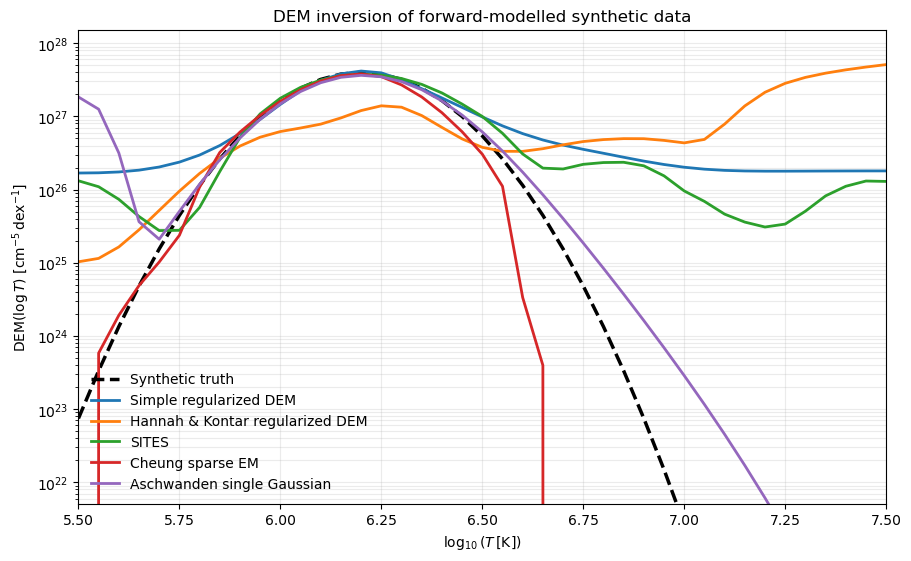

In [5]:
display_labels = {
    'simple_reg_dem': 'Simple regularized DEM',
    'demreg': 'Hannah & Kontar regularized DEM',
    'dem_sites': 'SITES',
    'cheung_sparse_em': 'Cheung sparse EM',
    'aschwanden_aia_teem': 'Aschwanden single Gaussian',
}

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
ax.plot(logt, true_profile, color='black', linestyle='--', linewidth=2.5,
        label='Synthetic truth')
for solver_name, result in results.items():
    ax.plot(logt, result['profile'], linewidth=2, label=display_labels[solver_name])
ax.set_yscale('log')
profile_peak = max(
    [true_profile.max()] + [result['profile'].max() for result in results.values()]
)
ax.set_ylim(profile_peak * 1e-6, profile_peak * 3)
ax.set_xlabel(r'$\log_{10}(T\,[\mathrm{K}])$')
ax.set_ylabel(r'$\mathrm{DEM}(\log T)\ [\mathrm{cm^{-5}}\,\mathrm{dex^{-1}}]$')
ax.set_title('DEM inversion of forward-modelled synthetic data')
ax.set_xlim(logt[0], logt[-1])
ax.grid(alpha=0.25, which='both')
ax.legend(frameon=False)
plt.show()

In [6]:
true_peak_logt = float(logt[np.argmax(true_profile)])
print(f'truth: peak logT = {true_peak_logt:.2f}, total EM = {true_area:.3e} cm^-5')
print()
print(f'{"solver":24s} {"peak logT":>9s} {"EM ratio":>9s} {"L2 err (norm)":>13s}')
for solver_name, result in results.items():
    profile = result['profile']
    area = float(_trapezoid(profile, logt))
    peak = float(logt[np.argmax(profile)])
    l2 = float(np.sqrt(_trapezoid(
        (result['normalized_profile'] - true_normalized) ** 2, logt
    )))
    print(f'{solver_name:24s} {peak:9.2f} {area / true_area:9.3f} {l2:13.4f}')

truth: peak logT = 6.20, total EM = 1.504e+27 cm^-5

solver                   peak logT  EM ratio L2 err (norm)
simple_reg_dem                6.20     1.236        0.3048
demreg                        7.50     1.395        1.4852
dem_sites                     6.20     1.141        0.2203
cheung_sparse_em              6.20     0.887        0.1342
aschwanden_aia_teem           6.20     1.022        0.3029


## 해석과 주의점

- forward와 역산이 **같은 온도응답, 같은 41-bin logT 격자**를 사용하므로 이것은 가장 이상적인 self-consistency 테스트다(이른바 inverse crime). 실제 관측 역산 성능의 **상한**으로 해석해야 한다.
- 그래도 solver별 bias는 그대로 드러난다. 예로 `aschwanden_aia_teem`은 단일 Gaussian 가정이라 `SYNTH_COMPONENTS`에 성분을 2개 이상 넣으면 구조적으로 정답을 복원할 수 없다.
- `SYNTH_COMPONENTS`(peak 위치·폭·amplitude), noise 수준(`SYSTEMATIC_FRACTION`), `N_SYNTH_PIXELS`를 바꿔가며 각 solver의 복원 한계(폭 과대평가, 고온 꼬리, 저온/고온 경계에서의 실패 등)를 확인하는 용도로 쓴다.
- EM ratio는 복원 profile의 ∫DEM dlogT를 정답값으로 나눈 것, L2 err는 정규화 profile 차이의 L2 norm이다.